In [1]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.linear_model import TheilSenRegressor
from scipy.spatial.distance import pdist, squareform


def distance_corr(x, y, eps=1e-12):
    """Distance correlation between two arrays (same number of observations)."""
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim == 1:
        x = x[:, None]
    if y.ndim == 1:
        y = y[:, None]
    if x.shape[0] != y.shape[0]:
        raise ValueError(f"x and y must have the same number of observations.")
    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return 0.0
    A = squareform(pdist(x, metric="euclidean"))
    B = squareform(pdist(y, metric="euclidean"))
    A = A - A.mean(axis=0, keepdims=True) - A.mean(axis=1, keepdims=True) + A.mean()
    B = B - B.mean(axis=0, keepdims=True) - B.mean(axis=1, keepdims=True) + B.mean()
    dcov2 = np.mean(A * B)
    dvarx = np.mean(A * A)
    dvary = np.mean(B * B)
    if dvarx < eps or dvary < eps:
        return 0.0
    return float(np.sqrt(max(dcov2, 0.0) / np.sqrt(dvarx * dvary)))


# -----------------------------
# Expression helpers
# -----------------------------
def get_X(adata, layer=None):
    X = adata.layers[layer] if layer is not None else adata.X
    if sparse.issparse(X):
        X = X.toarray()
    return np.asarray(X)


def condition_mean(adata, p_key, condition, layer=None):
    X = get_X(adata, layer=layer)
    mask = adata.obs[p_key].astype(str).values == str(condition)
    if mask.sum() == 0:
        raise ValueError(f"No cells found for condition={condition}")
    return X[mask].mean(axis=0)


def parse_combo(combo, sep="+"):
    combo = str(combo)
    if sep in combo:
        a, b = combo.split(sep, 1)
    else:
        raise ValueError(f"Could not parse combo: {combo}")
    return a, b


def gi_metrics(delta_a, delta_b, delta_ab, eps=1e-12):
    """
    Fit the Norman 2019 linear model  δab ≈ c1·δa + c2·δb  via Theil-Sen
    robust regression and return all derived metrics.

    Parameters match the supplement exactly:
        fit_intercept=False, max_subpopulation=1e5, max_iter=1000, random_state=1000
    """
    X = np.vstack([delta_a, delta_b]).T
    y = delta_ab

    reg = TheilSenRegressor(
        fit_intercept=False,
        max_subpopulation=100_000,
        max_iter=1000,
        random_state=1000,
    )
    reg.fit(X, y)

    c1, c2 = reg.coef_
    pred = reg.predict(X)

    magnitude = np.sqrt(c1**2 + c2**2)

    dominance = np.nan
    if abs(c1) > eps and abs(c2) > eps:
        dominance = abs(np.log10(abs(c1 / c2)))

    dcor_fit          = distance_corr(pred, delta_ab)
    dcor_singles      = distance_corr(delta_a, delta_b)
    dcor_first        = distance_corr(delta_a, delta_ab)
    dcor_second       = distance_corr(delta_b, delta_ab)

    max_dcor  = max(dcor_first, dcor_second)
    min_dcor  = min(dcor_first, dcor_second)
    dcor_ratio = min_dcor / max_dcor if max_dcor > eps else 0.0

    dcor_single_to_double = distance_corr(
        np.vstack([delta_a, delta_b]).T, delta_ab,
    )

    return {
        "c1": c1,
        "c2": c2,
        "magnitude": magnitude,
        "dominance": dominance,
        "dcor_fit": dcor_fit,
        "dcor_singles": dcor_singles,
        "dcor_first": dcor_first,
        "dcor_second": dcor_second,
        "dcor_ratio": dcor_ratio,
        "dcor_single_to_double": dcor_single_to_double,
    }


_LOG10_2P5 = float(np.log10(2.5))   # ≈ 0.398

# Columns that must be present for classify_gi to run.
_METRIC_COLS = ("c1", "c2", "magnitude", "dcor_fit", "dcor_singles")

# Labels that mark rows without valid metrics (no regression was run).
_SKIP_LABELS = {"missing_single_or_combo", "too few cells"}


def classify_gi(
    row,
    *,
    neomorphic_fit_thresh=0.7,
    redundant_singles_thresh=0.6,
    dominance_min_log10=_LOG10_2P5,
    potentiation_min_coef=1.1,
    potentiation_min_mag=1.8,
    synergy_min_coef=1.0,
    suppression_coef_max=0.9,
    similar_singles_thresh=0.4,
):
    """
    Norman 2019-style transcriptional GI classification (mutually exclusive tree).

    Decision order:
        1. Neomorphic          d_fit < neomorphic_fit_thresh
        2. Redundant (early)   dcor(a,b) > redundant_singles_thresh  AND  c1+c2 < 2.0
        3. Epistasis /         |log10(c1/c2)| > dominance_min_log10
           Potentiation
        4. Potentiation        balanced  AND  mag > potentiation_min_mag
        5. Synergy             balanced  AND  max(c1,c2) > synergy_min_coef
        6. Suppression         balanced  AND  max(c1,c2) < suppression_coef_max
        7. Redundant /
           Approx-additive     split by dcor(a,b) vs similar_singles_thresh

    Returns: (GI_label, GI_label) — same string twice for CSV compatibility.
    """
    c1        = row["c1"]
    c2        = row["c2"]
    mag       = row["magnitude"]
    d_fit     = row["dcor_fit"]
    d_singles = row["dcor_singles"]
    eps = 1e-12

    if d_fit < neomorphic_fit_thresh:
        return "neomorphic", "neomorphic"

    if c1 > 0 and c2 > 0 and d_singles > redundant_singles_thresh and (c1 + c2) < 2.0:
        return "redundant", "redundant"

    log_dom = abs(np.log10(max(abs(c1), eps) / max(abs(c2), eps)))
    if log_dom > dominance_min_log10:
        if max(abs(c1), abs(c2)) > potentiation_min_coef:
            return "potentiation", "potentiation"
        return "epistasis", "epistasis"

    if mag > potentiation_min_mag:
        return "potentiation", "potentiation"

    if max(abs(c1), abs(c2)) > synergy_min_coef:
        if d_singles > similar_singles_thresh:
            return "synergy (similar phenotype)", "synergy (similar phenotype)"
        return "synergy (dissimilar phenotype)", "synergy (dissimilar phenotype)"

    if max(abs(c1), abs(c2)) < suppression_coef_max:
        return "suppression", "suppression"

    if d_singles > similar_singles_thresh:
        return "redundant", "redundant"

    return "approximately additive", "approximately additive"


def reclassify_gi_labels(df, **kwargs):
    """
    Re-apply classify_gi to a metrics DataFrame without re-running the regression.

    Use this for fast threshold tuning after the initial compute_norman_gi_labels run.
    Rows with non-metric labels (e.g. 'too few cells') are passed through unchanged.

    Parameters
    ----------
    df     : DataFrame returned by compute_norman_gi_labels (must contain metric columns).
    **kwargs : Any classify_gi threshold keyword arguments to override.

    Returns
    -------
    Copy of df with updated GI_label and all_possible_labels columns.

    Example
    -------
    gi_df2 = reclassify_gi_labels(gi_df, neomorphic_fit_thresh=0.65, suppression_coef_max=0.85)
    print(gi_df2["GI_label"].value_counts())
    """
    missing = [c for c in _METRIC_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame is missing metric columns: {missing}. "
                         "Run compute_norman_gi_labels first.")

    out = df.copy()
    for idx, row in df.iterrows():
        if row.get("GI_label", "") in _SKIP_LABELS:
            continue
        label, all_labels = classify_gi(row, **kwargs)
        out.at[idx, "GI_label"]          = label
        out.at[idx, "all_possible_labels"] = all_labels
    return out


# -----------------------------
# Main exporter
# -----------------------------
def compute_norman_gi_labels(
    adata,
    p_key,
    ctrl_label="ctrl",
    combo_sep="+",
    layer=None,
    combos=None,
    min_cells_single=10,
    min_cells_combo=10,
    output_csv="norman_style_GI_labels.csv",
):
    """
    Run the full Norman 2019 pipeline: compute delta vectors, fit Theil-Sen
    regression per combination, and classify.  This is the slow step (~minutes).
    After the first run, use reclassify_gi_labels() to change thresholds instantly.

    Parameters
    ----------
    adata      : AnnData. Use layer='znorm' for Norman-faithful normalization.
    p_key      : obs column with perturbation names.
    ctrl_label : NTC label.
    combo_sep  : Combo separator ('+').
    layer      : AnnData layer ('znorm' recommended).
    combos     : Explicit combo list; inferred from p_key if None.
    output_csv : Where to write results.
    """
    obs = adata.obs.copy()
    obs[p_key] = obs[p_key].astype(str)
    conditions = set(obs[p_key].unique())
    ctrl = condition_mean(adata, p_key, ctrl_label, layer=layer)

    if combos is None:
        combos = [c for c in sorted(conditions) if combo_sep in c]

    rows = []
    for combo in combos:
        try:
            gene_a, gene_b = parse_combo(combo, sep=combo_sep)
        except Exception:
            continue

        if gene_a not in conditions or gene_b not in conditions or combo not in conditions:
            rows.append({"combination": combo, "gene_a": gene_a, "gene_b": gene_b,
                         "GI_label": "missing_single_or_combo", "all_possible_labels": ""})
            continue

        n_a  = int((obs[p_key] == gene_a).sum())
        n_b  = int((obs[p_key] == gene_b).sum())
        n_ab = int((obs[p_key] == combo).sum())

        if n_a < min_cells_single or n_b < min_cells_single or n_ab < min_cells_combo:
            rows.append({"combination": combo, "gene_a": gene_a, "gene_b": gene_b,
                         "n_a": n_a, "n_b": n_b, "n_ab": n_ab,
                         "GI_label": "too few cells", "all_possible_labels": ""})
            continue

        mean_a  = condition_mean(adata, p_key, gene_a,  layer=layer)
        mean_b  = condition_mean(adata, p_key, gene_b,  layer=layer)
        mean_ab = condition_mean(adata, p_key, combo,   layer=layer)

        delta_a  = mean_a  - ctrl
        delta_b  = mean_b  - ctrl
        delta_ab = mean_ab - ctrl

        metrics = gi_metrics(delta_a, delta_b, delta_ab)
        label, all_labels = classify_gi(metrics)

        rows.append({"combination": combo, "gene_a": gene_a, "gene_b": gene_b,
                     "n_a": n_a, "n_b": n_b, "n_ab": n_ab,
                     "GI_label": label, "all_possible_labels": all_labels,
                     **metrics})

    out = pd.DataFrame(rows)
    out.to_csv(output_csv, index=False)
    return out


In [2]:
import scanpy as sc
import sys
sys.path.append('../../..')
import sherlock as slk

data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


In [3]:
import scipy.sparse as sp

# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# Norman 2019: use all genes with mean expression > 0.5 UMI per cell (~2800 genes).
# data.X still holds raw counts at this point.
raw_X = data.X
mean_expr = np.array(raw_X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5

# Always keep perturbation target genes so their expression is available.
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

n_expr     = int(expr_mask[keep_mask].sum())
n_pert_only = int((pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum())
print(f"Kept {data.n_vars} genes  ({n_expr} with mean > 0.5 UMI + {n_pert_only} pert-only)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")


Kept 3270 genes  (3190 with mean > 0.5 UMI + 80 pert-only)
Pert genes in var_names: 102 / 105


In [4]:
sc.pp.normalize_total(data, target_sum=1e4)
sc.pp.log1p(data)

# Norman 2019 normalization: z-normalize each gene w.r.t. NTC cells so the
# NTC centroid sits at the origin.  Delta vectors are then directly interpretable
# as deviations from the unperturbed state in units of NTC standard deviations.
X_log    = data.X.toarray() if sp.issparse(data.X) else np.array(data.X)
ntc_mask = data.obs[p_key].values == NTC
ntc_mean = X_log[ntc_mask].mean(axis=0)
ntc_std  = X_log[ntc_mask].std(axis=0)
ntc_std  = np.where(ntc_std < 1e-8, 1.0, ntc_std)   # avoid division by zero
data.layers['znorm'] = (X_log - ntc_mean) / ntc_std
print(f"znorm layer created: NTC mean range [{ntc_mean.min():.3f}, {ntc_mean.max():.3f}]")


znorm layer created: NTC mean range [0.000, 5.003]


In [5]:
gi_df = compute_norman_gi_labels(
    data,
    p_key=p_key,
    ctrl_label=NTC,
    combo_sep="+",
    layer='znorm',          # Norman 2019: z-normalized expression
    output_csv="norman_style_GI_labels.csv",
)

print(gi_df["GI_label"].value_counts())
gi_df.head()


GI_label
suppression                       41
redundant                         24
synergy (similar phenotype)       21
neomorphic                        16
epistasis                         11
synergy (dissimilar phenotype)     6
potentiation                       6
approximately additive             6
Name: count, dtype: int64


,combination,gene_a,gene_b,n_a,n_b,n_ab,GI_label,all_possible_labels,c1,c2,magnitude,dominance,dcor_fit,dcor_singles,dcor_first,dcor_second,dcor_ratio,dcor_single_to_double
0,AHR+FEV,AHR,FEV,558,703,276,synergy (dissimilar phenotype),synergy (dissimilar phenotype),1.308125,0.831912,1.550248,0.196572,0.850951,0.380986,0.709605,0.676246,0.952990,0.792848
1,AHR+KLF1,AHR,KLF1,558,1954,481,epistasis,epistasis,0.236839,1.010197,1.037589,0.629953,0.804122,0.243936,0.176490,0.734964,0.240134,0.583283
2,BAK1+BCL2L11,BAK1,BCL2L11,1451,582,175,neomorphic,neomorphic,0.726729,0.089397,0.732207,0.910049,0.330226,0.103508,0.327043,0.084336,0.257876,0.286239
3,BAK1+KLF1,BAK1,KLF1,1451,1954,392,epistasis,epistasis,0.249519,0.890762,0.925050,0.552657,0.825588,0.207121,0.247662,0.816522,0.303313,0.816898
4,BAK1+TMSB4X,BAK1,TMSB4X,1451,542,328,neomorphic,neomorphic,0.138645,0.636363,0.651291,0.661800,0.403854,0.147068,0.077401,0.391440,0.197734,0.382850


In [6]:
# ── Threshold tuning — no regression re-run needed ───────────────────────────
# gi_df already holds all metrics (c1, c2, magnitude, dcor_fit, dcor_singles …).
# reclassify_gi_labels re-applies classify_gi in milliseconds.
#
# Current defaults (edit and re-run this cell to iterate):
gi_tuned = reclassify_gi_labels(
    gi_df,
    neomorphic_fit_thresh   = 0.70,   # d_fit below this → neomorphic
    redundant_singles_thresh= 0.60,   # dcor(a,b) > this AND c1+c2 < 2 → redundant
    dominance_min_log10     = np.log10(2.5),  # |log10(c1/c2)| threshold for epistasis
    potentiation_min_coef   = 1.10,   # dominant coef must exceed this for potentiation
    potentiation_min_mag    = 1.80,   # balanced large magnitude → potentiation
    synergy_min_coef        = 1.00,   # at least one coef > this → synergy
    suppression_coef_max    = 0.90,   # max(c1,c2) below this → suppression
    similar_singles_thresh  = 0.40,   # dcor(a,b) boundary for similar/dissimilar
)

print(gi_tuned["GI_label"].value_counts())
gi_tuned[gi_tuned['combination'].str.contains('CNN1')]


GI_label
suppression                       41
redundant                         24
synergy (similar phenotype)       21
neomorphic                        16
epistasis                         11
synergy (dissimilar phenotype)     6
potentiation                       6
approximately additive             6
Name: count, dtype: int64


,combination,gene_a,gene_b,n_a,n_b,n_ab,GI_label,all_possible_labels,c1,c2,magnitude,dominance,dcor_fit,dcor_singles,dcor_first,dcor_second,dcor_ratio,dcor_single_to_double
13,CBL+CNN1,CBL,CNN1,663,765,348,synergy (similar phenotype),synergy (similar phenotype),1.329734,1.011822,1.670921,0.118661,0.763200,0.658119,0.702736,0.691687,0.984277,0.754886
34,CEBPE+CNN1,CEBPE,CNN1,1230,765,237,suppression,suppression,0.514767,0.600724,0.791109,0.067064,0.816845,0.287103,0.723637,0.511896,0.707393,0.765472
44,CNN1+ETS2,CNN1,ETS2,765,1201,904,suppression,suppression,0.749860,0.629727,0.979207,0.075828,0.838733,0.180092,0.600497,0.476683,0.793814,0.689141
45,CNN1+MAPK1,CNN1,MAPK1,765,763,398,suppression,suppression,0.637587,0.765419,0.996185,0.079360,0.835071,0.159107,0.370867,0.715334,0.518454,0.739246
46,CNN1+UBASH3A,CNN1,UBASH3A,765,817,177,potentiation,potentiation,1.463620,1.702072,2.244824,0.065550,0.701963,0.422314,0.639181,0.532371,0.832895,0.678368
47,CNN1+UBASH3B,CNN1,UBASH3B,765,1201,401,potentiation,potentiation,1.037111,1.549339,1.864417,0.174321,0.838842,0.668391,0.756429,0.774948,0.976103,0.825842


In [12]:
gi_df.to_csv("GI_labels.csv", index=False)

In [10]:
gi_df[gi_df['combination'].str.contains('CBL')]

,combination,gene_a,gene_b,n_a,n_b,n_ab,GI_label,all_possible_labels,c1,c2,magnitude,dominance,dcor_fit,dcor_singles,dcor_first,dcor_second,dcor_ratio,dcor_single_to_double
13,CBL+CNN1,CBL,CNN1,663,765,348,synergy (similar phenotype),synergy (similar phenotype),1.329734,1.011822,1.670921,0.118661,0.763200,0.658119,0.702736,0.691687,0.984277,0.754886
14,CBL+PTPN12,CBL,PTPN12,663,445,333,redundant,redundant,0.989845,0.709861,1.218071,0.144394,0.814394,0.674915,0.749703,0.743698,0.991989,0.805528
15,CBL+PTPN9,CBL,PTPN9,663,444,305,redundant,redundant,1.013582,0.949950,1.389155,0.028158,0.800669,0.608281,0.715071,0.718602,0.995087,0.786373
16,CBL+TGFBR2,CBL,TGFBR2,663,644,187,neomorphic,neomorphic,1.109066,0.406592,1.181247,0.435798,0.680822,0.111631,0.670196,0.192735,0.287580,0.664534
17,CBL+UBASH3A,CBL,UBASH3A,663,817,64,neomorphic,neomorphic,1.164446,0.709789,1.363721,0.214990,0.529218,0.593741,0.516471,0.409459,0.792803,0.526585
18,CBL+UBASH3B,CBL,UBASH3B,663,1201,406,potentiation,potentiation,0.991264,1.639495,1.915868,0.218521,0.822525,0.755452,0.751748,0.788287,0.953648,0.815271


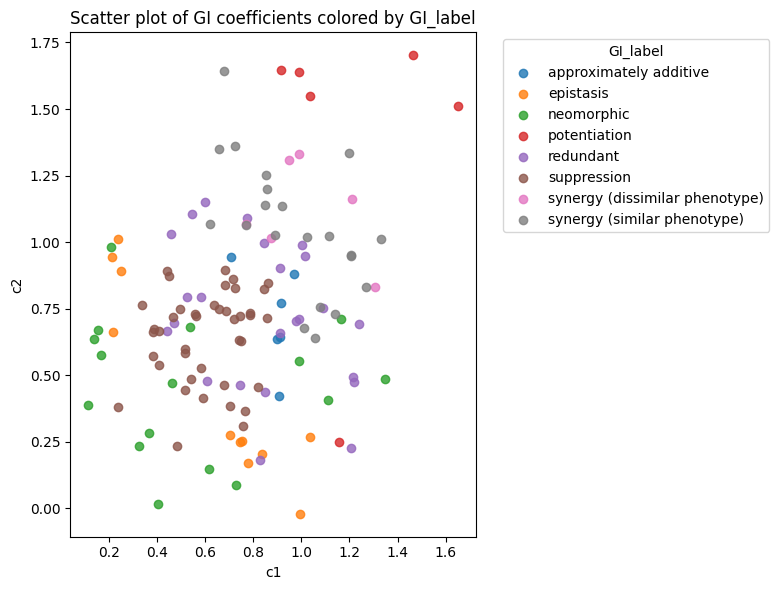

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for label, group in gi_df.groupby("GI_label"):
    ax.scatter(group["c1"], group["c2"], label=label, alpha=0.8)

ax.set_xlabel("c1")
ax.set_ylabel("c2")
ax.set_title("Scatter plot of GI coefficients colored by GI_label")
ax.legend(title="GI_label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()